In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [2]:
# loading data
df = pd.read_csv("data/cleaned_ecommerce_data.csv")
df.head()

,order_id,customer_name,age,gender,city,order_date,product_name,category,unit_price,quantity,email,payment_method,status
0,ORD-10537,Maham Raza,60.0,Male,Islamabad,2025-02-06,Headphones,Accessories,9238.84,1,maham.raza29@gmail.com,EasyPaisa,Pending
1,ORD-10016,Maham Sheikh,34.0,Female,Sialkot,2024-06-18,Smart Watch,Accessories,11754.36,4,maham.sheikh17@gmail.com,Bank Transfer,Pending
2,ORD-10620,Hamza Sheikh,18.0,Female,Multan,2025-08-11,Monitor,Electronics,44713.92,3,hamza.sheikh90@gmail.com,EasyPaisa,Returned
3,ORD-10254,Ahmed Ahmed,56.0,Male,Multan,2025-05-22,Keyboard,Accessories,4363.75,2,ahmed.ahmed33@gmail.com,Cash,Pending
4,ORD-10527,Hina Butt,37.0,Male,Rawalpindi,2024-01-25,Monitor,Electronics,41632.93,2,hina.butt42@gmail.com,Bank Transfer,Returned


In [3]:
# adding a new column "revenue" for better analysis
df['revenue'] = df['unit_price'] * df['quantity']
df.head()

,order_id,customer_name,age,gender,city,order_date,product_name,category,unit_price,quantity,email,payment_method,status,revenue
0,ORD-10537,Maham Raza,60.0,Male,Islamabad,2025-02-06,Headphones,Accessories,9238.84,1,maham.raza29@gmail.com,EasyPaisa,Pending,9238.84
1,ORD-10016,Maham Sheikh,34.0,Female,Sialkot,2024-06-18,Smart Watch,Accessories,11754.36,4,maham.sheikh17@gmail.com,Bank Transfer,Pending,47017.44
2,ORD-10620,Hamza Sheikh,18.0,Female,Multan,2025-08-11,Monitor,Electronics,44713.92,3,hamza.sheikh90@gmail.com,EasyPaisa,Returned,134141.76
3,ORD-10254,Ahmed Ahmed,56.0,Male,Multan,2025-05-22,Keyboard,Accessories,4363.75,2,ahmed.ahmed33@gmail.com,Cash,Pending,8727.50
4,ORD-10527,Hina Butt,37.0,Male,Rawalpindi,2024-01-25,Monitor,Electronics,41632.93,2,hina.butt42@gmail.com,Bank Transfer,Returned,83265.86


## Which Category generates the most total revenue?

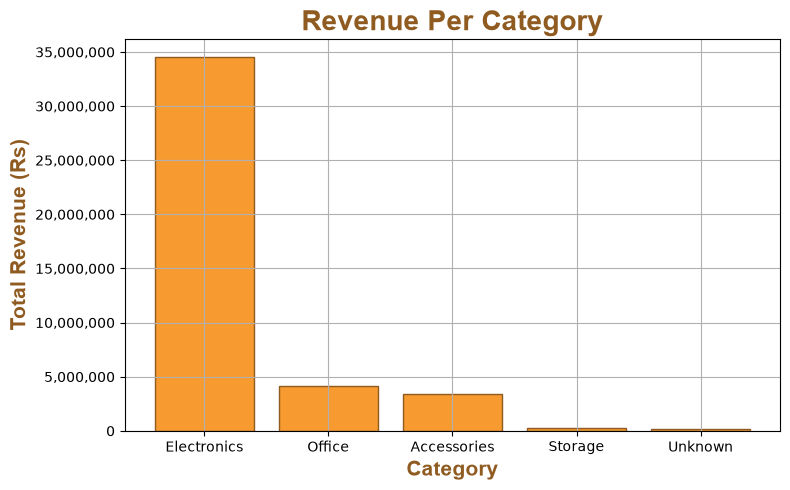

In [4]:
revenue_by_category = df.groupby('category')['revenue'].sum().sort_values(ascending=False)

x_category = revenue_by_category.index
y_revenue = revenue_by_category.values

plt.figure(figsize=(8,5))
plt.bar(x_category, y_revenue, color="#f79a2f",
                               edgecolor="#8f5b21")
plt.xlabel("Category", fontsize=15,
                       family="Arial",
                       color="#8f5b21",
                       fontweight="bold")

plt.ylabel("Total Revenue (Rs)", fontsize=15,
                                 family="Arial",
                                 color="#8f5b21",
                                 fontweight="bold")

plt.ticklabel_format(style='plain',axis='y')
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{x:,.0f}'))

plt.title("Revenue Per Category", fontsize=20,
                                  family="Arial",
                                  color="#8f5b21",
                                  fontweight="bold")

plt.grid()
plt.tight_layout()
plt.savefig("images/revenue_per_category.png", dpi=300, transparent=False)
plt.show()

### Insight: Revenue by Category

Electronics generates approximately Rs 34.5 million in revenue — over 8x more than the next 
highest category, Office (~Rs 4.18 million), and roughly 10x more than Accessories (~Rs 3.42 million). 
Storage and Unknown together contribute less than Rs 450,000 combined, making them negligible 
in comparison. This shows the business's revenue is heavily concentrated in a single category.

## Which payment method is used most often?

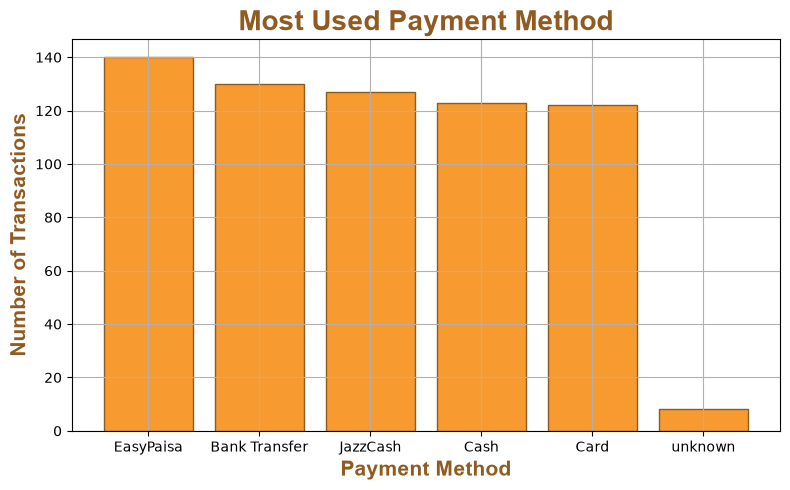

In [5]:
p_method = df['payment_method'].value_counts(ascending=False)

plt.figure(figsize=(8,5))
plt.bar(p_method.index, p_method.values, color="#f79a2f", edgecolor="#8f5b21")

plt.xlabel("Payment Method", fontsize=15,
                             family="Arial",
                             color="#8f5b21",
                             fontweight="bold")

plt.ylabel("Number of Transactions", fontsize=15,
                                     family="Arial",
                                     color="#8f5b21",
                                     fontweight="bold")

plt.title("Most Used Payment Method", fontsize=20,
                                      family="Arial",
                                      color="#8f5b21",
                                      fontweight="bold")

plt.tight_layout()
plt.grid()
plt.savefig("images/most_used_payment_method.png", dpi=300, transparent=False)
plt.show()

### Insight: Most Used Payment Method

EasyPaisa is the most used payment method with 140 transactions, followed by Bank Transfer (130), 
JazzCash (127), Cash (123), and Card (122). Usage is fairly balanced across the top five methods, 
with only a small gap between the highest and lowest. Just 8 transactions have an unknown payment 
method, a minor data quality gap compared to the "Unknown" category seen in the revenue data.

## How do orders vary by month/year, if your dataset has a date column?

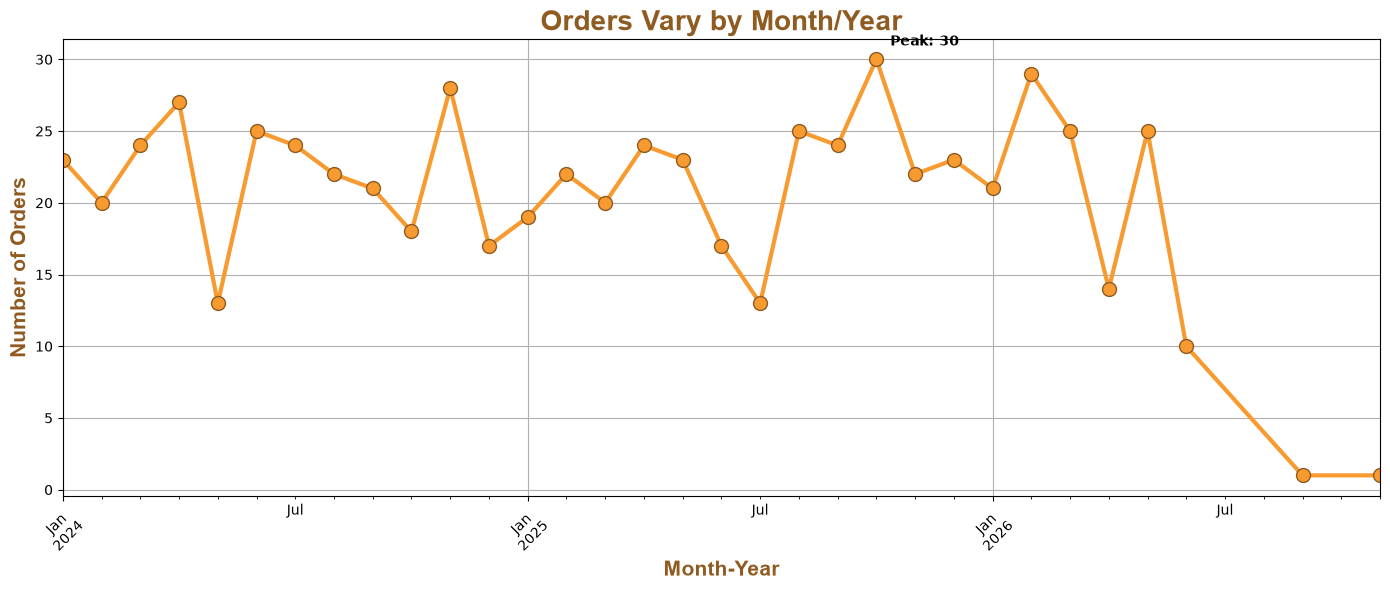

In [40]:
df['order_date'] = pd.to_datetime(df['order_date'])

# creating a month_year column to groupby
df['month_year'] = df['order_date'].dt.to_period('M')

orders_by_month = df.groupby('month_year')['order_id'].count()

plt.figure(figsize=(14,6))
orders_by_month.plot(kind='line', marker='o',
                                  markersize=10,
                                  markerfacecolor="#f79a2f",
                                  markeredgecolor="#8f5b21",
                                  linestyle="solid",
                                  linewidth=3,
                                  color="#f79a2f")

plt.title("Orders Vary by Month/Year", fontsize=20,
                                       family="Arial",
                                       fontweight="bold",
                                       color="#8f5b21")

plt.xlabel("Month-Year", fontsize=15,
                         family="Arial",
                         color="#8f5b21",
                         fontweight="bold")
                         
plt.ylabel("Number of Orders", fontsize=15,
                               family="Arial",
                               color="#8f5b21",
                               fontweight="bold")

peak_month = orders_by_month.idxmax()
peak_value = orders_by_month.max()

plt.annotate(f'Peak: {peak_value}', xy=(peak_month, peak_value),
                                    xytext=(10,10), textcoords='offset points',
                                    weight='bold')

plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.savefig("images/orders_vary_by_month_year.png", dpi=300, transparent=False, bbox_inches="tight")
plt.show()

### Insight: Orders Over Time

Monthly order volume fluctuated between roughly 13 and 30 orders from Jan 2024 through late 2025, 
with no strong seasonal pattern. The sharp drop to near-zero in the final two months reflects 
incomplete data at the edge of the dataset rather than an actual business decline, and was 
excluded from trend interpretation.


## What's the breakdown of order status (e.g., delivered, cancelled, pending, returned)?

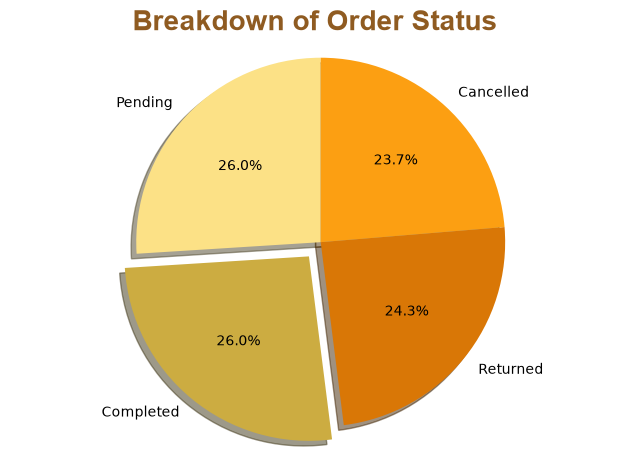

In [54]:
status_count = df['status'].value_counts()

plt.figure()

plt.pie(status_count, labels=status_count.index,
                      autopct='%1.1f%%',
                      startangle=90,
                      colors=['#fce186', '#ccac41', '#D97706', '#fc9f12'],
                      shadow=True,
                      explode=[0.0,0.1,0.0,0.0])

plt.title("Breakdown of Order Status", fontsize=20,
                                       family="Arial",
                                       fontweight="bold",
                                       color="#8f5b21")

plt.savefig("images/breakdown_of_order_status.png", dpi=300, transparent=False, bbox_inches="tight")
plt.axis('equal')
plt.tight_layout()
plt.show()

### Insight: Order Status Breakdown

Order outcomes are nearly evenly split across all four categories — Completed and Pending each account 
for 26.0%, Returned for 24.3%, and Cancelled for 23.7%. Unlike revenue (dominated by Electronics) or 
payment method (led by EasyPaisa), no single order status dominates, suggesting a balanced distribution 
across the dataset.